# SHEETAL PATIL | CLUSTERING ANALYSIS ASSIGNMENT

This notebook presents a comprehensive clustering analysis of the EastWest Airlines dataset. The goal is to segment customers based on their flying patterns, credit card usage, and mileage accumulation to better understand customer behavior.

**What is Clustering:**\
Clustering is an unsupervised machine learning technique used to group similar data points together based on their features, without using labeled data.\
**Goal:**\
Maximize similarity within clusters\
Minimize similarity between clusters\
**Objective:**\
Segment customers into different groups for better business decisions.

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [111]:
# Load the data
df = pd.read_csv('EastWestAirlines.csv')
# print the data
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


**Data Understanding**\
About this data:
The file EastWestAirlines contains information on passengers who belong to an airline’s frequent flier program.\
For each passenger the data include information on their mileage history and on different ways they accrued or spent miles in the last year.\
The goal is to try to identify clusters of passengers that have similar characteristics for the purpose of targeting different segments for different types of mileage offers.\
**Balance:** Number of miles eligible for award travel\
**Qual_miles:** Number of miles counted as qualifying for Topflight status\
**cc1_miles:** Number of miles earned with freq. flyer credit card in the past 12 months\
**cc2_miles:** Number of miles earned with Rewards credit card in the past 12 months\
**cc3_miles:** Number of miles earned with Small Business credit card in the past 12 months\
**Bonus_miles:** Number of miles earned from non-flight bonus transactions in the past 12 months\
**Bonus_trans:** Number of non-flight bonus transactions in the past 12 months\
**Flight_miles_12mo:** Number of flight miles in the past 12 months\
**Flight_trans_12:** Number of flight transactions in the past 12 months\
**Days_since_enrolled:** Number of days since enrolled in flier program\
**Award?:** whether that person had award flight (free flight) or not

In [112]:
# Get info about the columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [113]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [114]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [115]:
# Drop ID#
data = df.drop(columns=['ID#'])

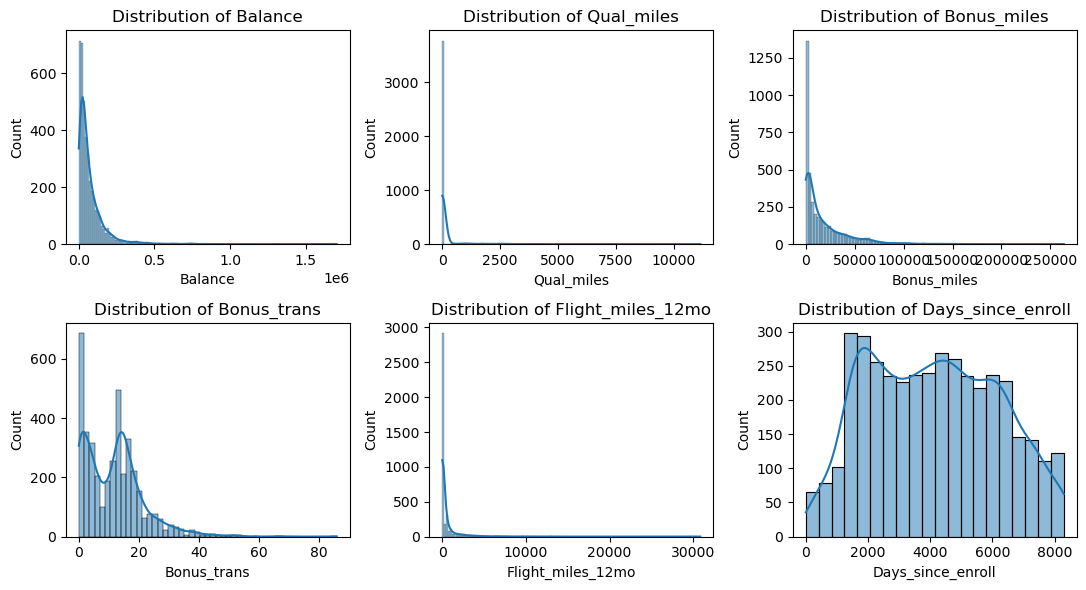

In [116]:
# EDA: Distribution of key features
plt.figure(figsize=(11, 6))
for i, col in enumerate(['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Days_since_enroll']):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

EDA: Histograms revealed that most customers have lower balances and fewer bonus transactions, while a small segment accounts for the majority of the airline's high-value activity.

**Correlation Heatmap**

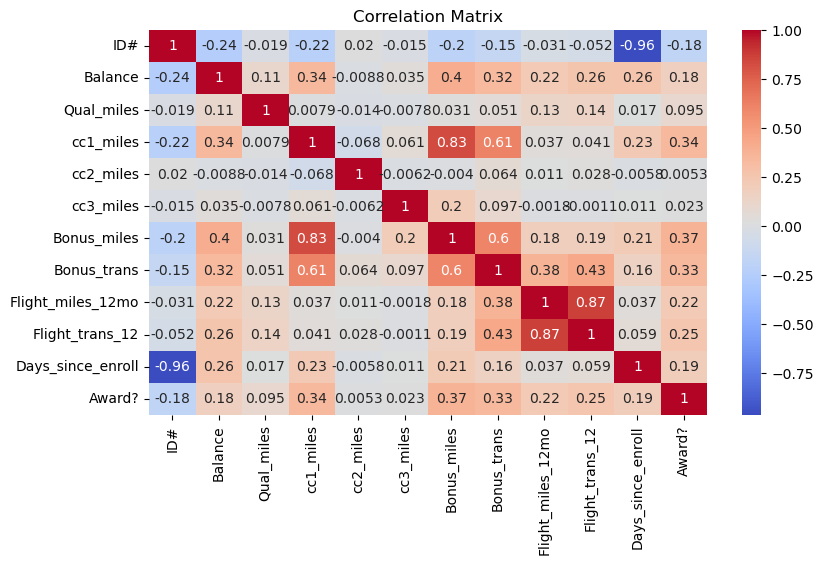

In [117]:
plt.figure(figsize=(9,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

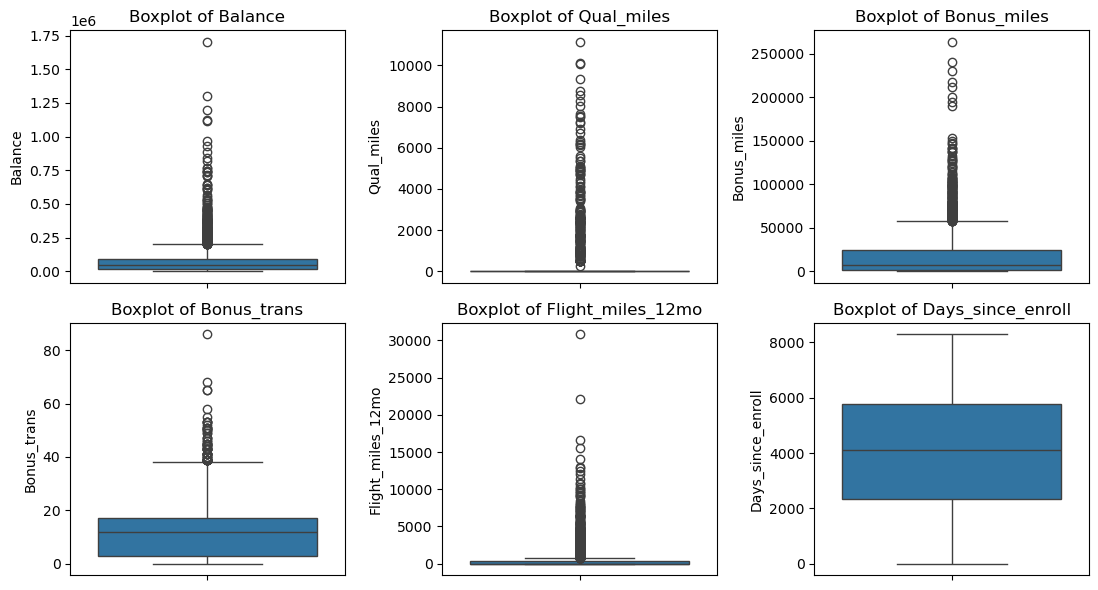

In [118]:
# Outlier check with Boxplots
plt.figure(figsize=(11, 6))
for i, col in enumerate(['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Days_since_enroll']):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Outlier Detection: Features like Balance, Bonus_miles, and Flight_miles_12mo exhibit significant outliers, representing the airline's "top-tier" or "elite" flyers.

**Feature Skewness Plot**

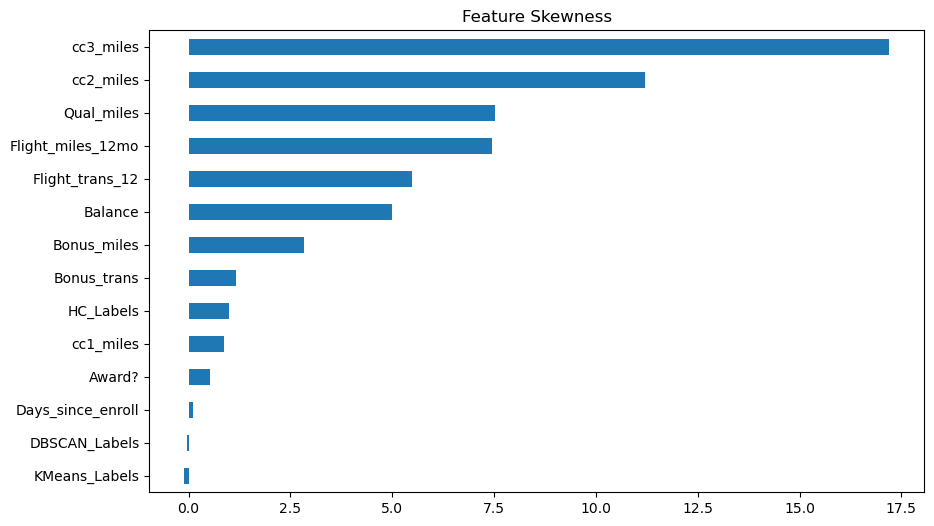

In [134]:
skewness = data.skew().sort_values()

plt.figure(figsize=(10,6))
skewness.plot(kind='barh')
plt.title("Feature Skewness")
plt.show()

In [120]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print("Data scaled successfully.")
scaled_df.head()

Data scaled successfully.


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918


**Feature Scaling:** Since variables like Balance (up to 1.7M) and cc1_miles (1-5) are on different scales, we applied StandardScaler to normalize the data.

**Distribution Plots for scaled data**

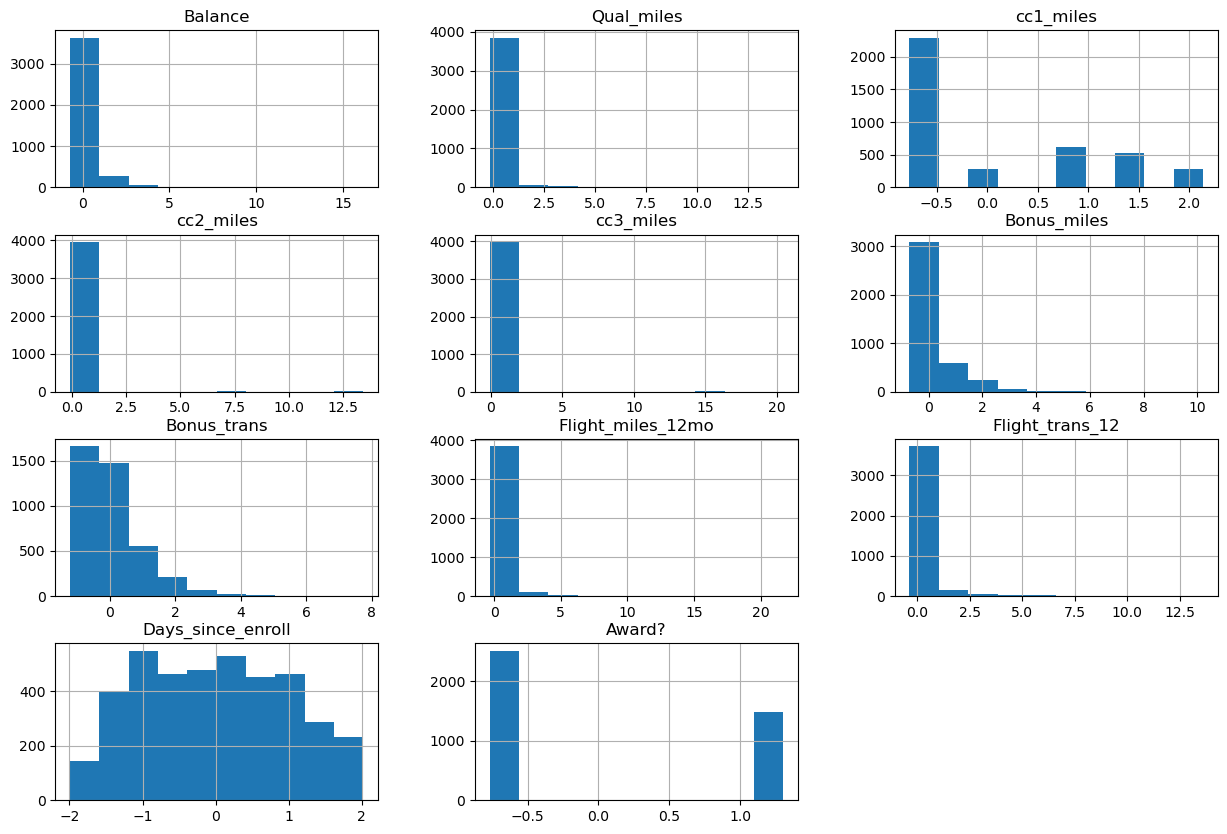

In [121]:
scaled_df.hist(figsize=(15,10))
plt.show()

**K-Means Clustering Concept**

K-Means divides data into K clusters by minimizing within-cluster variance.\
How it Works:\

Choose K centroids\
Assign points to nearest centroid\
Update centroids\
Repeat until convergence

Choosing K

Used Elbow Method:\
Plot WCSS vs K\
Optimal K = point where curve bends

In [122]:
# Find optimal K for KMeans using Elbow and Silhouette score
wcss = []
#Within-Cluster Sum of Squares → measures compactness of clusters
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

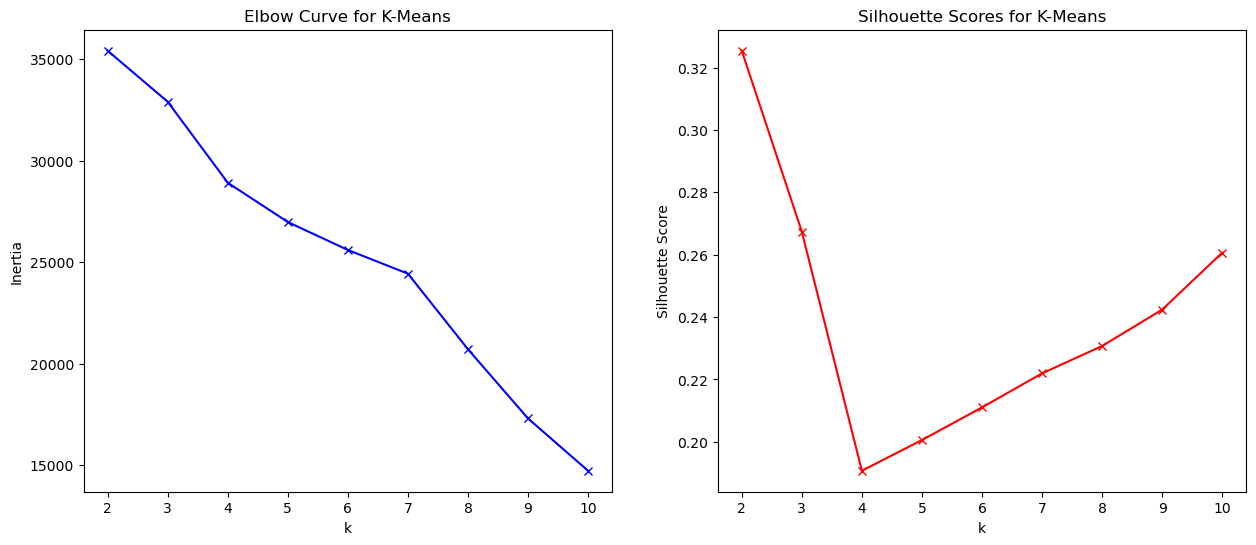

In [123]:
# Plot Elbow curve and Silhouette scores
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'rx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means')
plt.show()

In [124]:
# K-Means with optimal K=5 (looks like a good elbow and relatively high silhouette score)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
data['KMeans_Labels'] = kmeans_labels
print(f"K-Means silhouette score for k=5: {silhouette_score(scaled_data, kmeans_labels)}")

K-Means silhouette score for k=5: 0.2005393837499611


**Evaluation Metrics:  Silhouette Score**\
Range: -1 to +1\
Higher = better clustering

Used for:
K-Means and DBSCAN (excluding noise)

**Above is Implementation of Clustering Alogorithm: K Means**\
K-Means ClusteringOptimal K: The Elbow Curve and Silhouette scores suggested that $K=5$ provides a good balance between cluster compactness and separation.Silhouette Score: $0.201$

**Hierarchical Clustering Concept:**

Builds a tree-like structure (dendrogram) of clusters.

Types:\
Agglomerative (bottom-up) used here

Process:\
Each point is its own cluster\
Merge closest clusters step by step\
Continue until one cluster remains

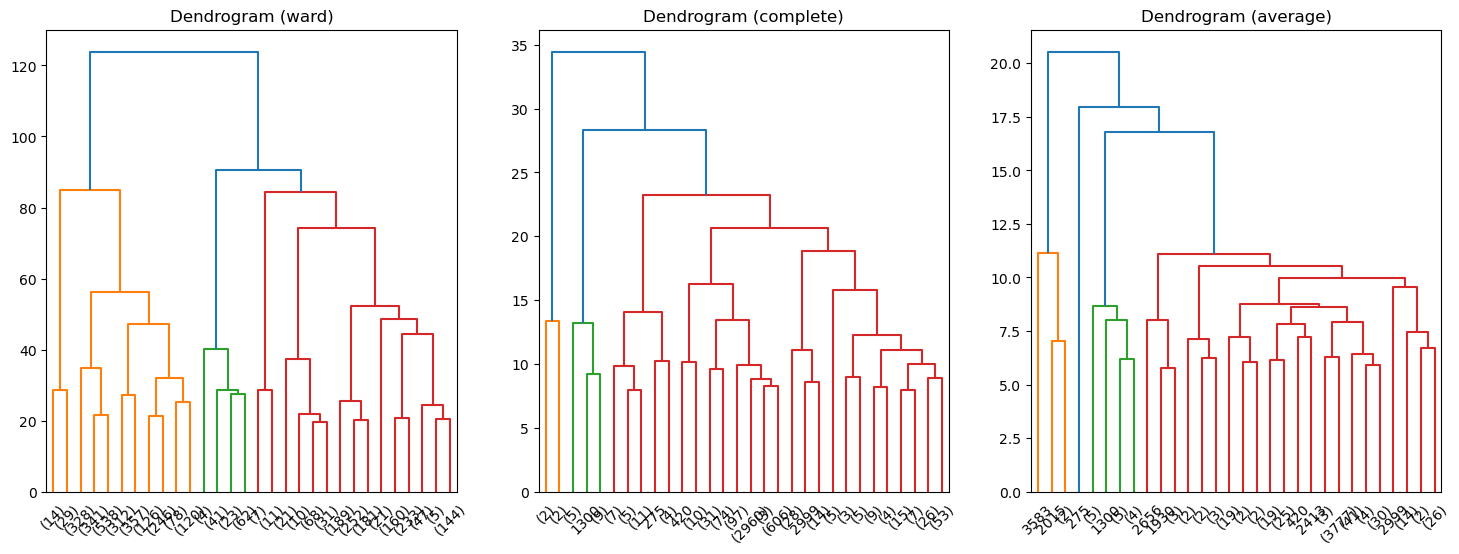

In [125]:
# Hierarchical Clustering
# For demonstration, I will use sample to avoid high computational cost (3999 points is fine but dendrogram is huge)

# Linkage methods: ward, complete, average
methods = ['ward', 'complete', 'average']
plt.figure(figsize=(18, 6))
for i, method in enumerate(methods):
    plt.subplot(1, 3, i + 1)
    Z = linkage(scaled_data, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30)
    plt.title(f'Dendrogram ({method})')
plt.show()

In [126]:
# Aglomerative Clustering with Ward (common) and k=5
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc_labels = hc.fit_predict(scaled_data)
data['HC_Labels'] = hc_labels
print(f"Hierarchical silhouette score for k=5 (ward): {silhouette_score(scaled_data, hc_labels)}")

Hierarchical silhouette score for k=5 (ward): 0.3098805307874414


**Above is Implementation of Clustering Alogorithm: Hierarchical Clustering**\
Hierarchical ClusteringMethodology: We used Agglomerative Clustering with Ward's linkage, which minimizes the variance within each cluster. Dendrograms were used to visualize the hierarchy.Silhouette Score: $0.310$ (Highest among all methods).

**DBSCAN ClusteringConcept:**

Density-based clustering:\
Groups points with high density\
Marks sparse points as noise

Parameters:\
eps → neighborhood radius\
min_samples → minimum points to form cluster

In [127]:
# DBSCAN
# Need to find optimal eps. Using k-distance plot is one way.

from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=2 * scaled_data.shape[1])
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)
distances = np.sort(distances[:, -1], axis=0)

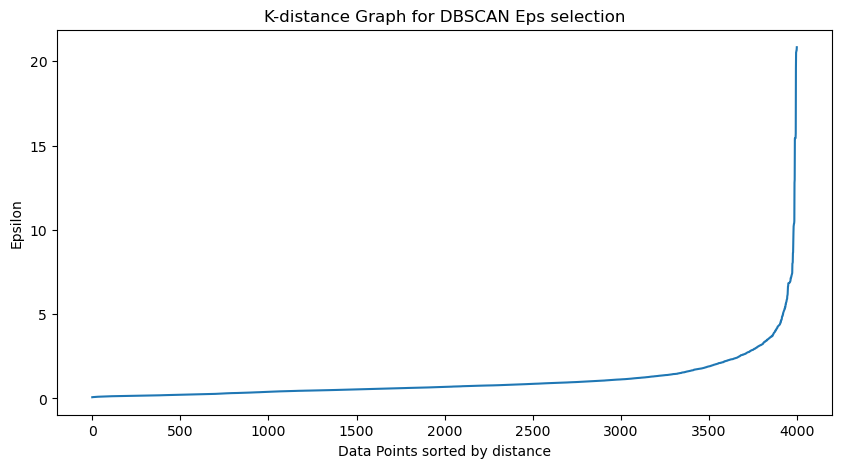

In [128]:
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN Eps selection')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon')
plt.show()

In [129]:
# Trying DBSCAN with eps and min_samples
# Let's try eps=1.0 and min_samples=22 (2*dims)
dbscan = DBSCAN(eps=1.0, min_samples=22)
db_labels = dbscan.fit_predict(scaled_data)
data['DBSCAN_Labels'] = db_labels

# Calculate silhouette for DBSCAN (only for non-noise points if multiple clusters exist)
if len(set(db_labels)) > 1:
    print(f"DBSCAN silhouette score: {silhouette_score(scaled_data, db_labels)}")
else:
    print("DBSCAN found only 1 cluster (including noise). Adjust parameters.")

# Save labels
data.to_csv('EastWestAirlines_Clustered.csv', index=False)

DBSCAN silhouette score: 0.21009837725614325


**Above is Implementation of Clustering Alogorithm: DBSCAN Clustering**\
DBSCAN (Density-Based Spatial Clustering of Applications with Noise)Parameter Tuning: Using a k-distance graph, an epsilon ($\epsilon$) of $1.0$ and $minPts$ of $22$ were chosen.Performance: DBSCAN was effective at identifying "noise" points (outliers) that do not fit into any regular cluster.Silhouette Score: $0.210$

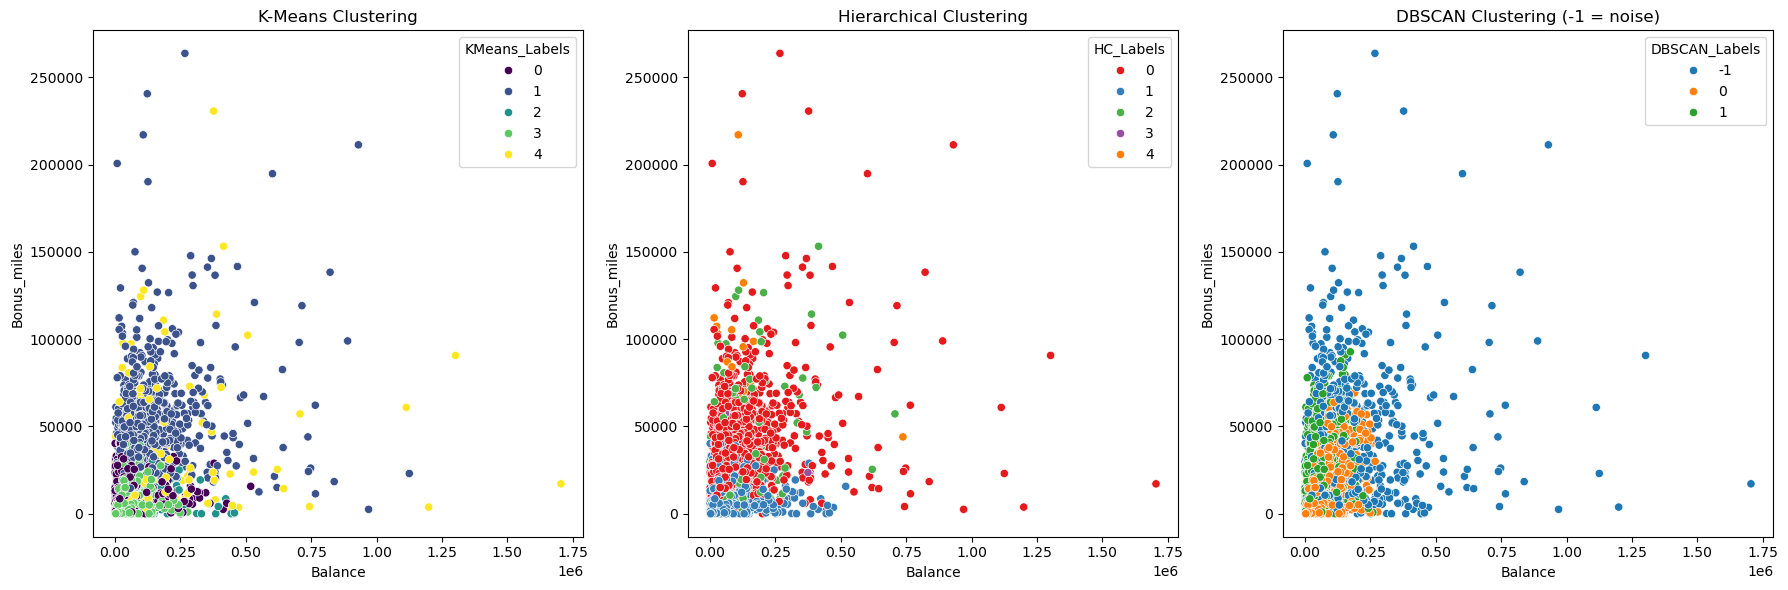

In [130]:
# Clustering visualisations: 
# Using Balance vs Bonus_miles
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='Balance', y='Bonus_miles', hue='KMeans_Labels', palette='viridis')
plt.title('K-Means Clustering')

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='Balance', y='Bonus_miles', hue='HC_Labels', palette='Set1')
plt.title('Hierarchical Clustering')

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='Balance', y='Bonus_miles', hue='DBSCAN_Labels', palette='tab10')
plt.title('DBSCAN Clustering (-1 = noise)')

plt.tight_layout()
plt.show()

The following plots visualize the identified segments:\
**Distributions & Boxplots:** Show the spread and outliers in the raw data.\
**Elbow & Silhouette Plots:** Justify the choice of $K=5$ for K-Means.\
**Dendrograms:** Illustrate the merging process in Hierarchical clustering.\
**Scatter Plots:** Show the final cluster assignments (using Balance vs. Bonus Miles).

In [131]:
# Cluster analysis: Group by KMeans and calculate means
cluster_summary = data.groupby('KMeans_Labels').mean()
print("K-Means Cluster Summary (Means):")
print(cluster_summary)

K-Means Cluster Summary (Means):
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Labels                                                               
0               58124.779499  193.427890   1.699642   1.019070   1.000000   
1              139193.010702  145.376932   4.195006   1.002378   1.057075   
2               59918.329626   70.803842   1.495450   1.020222   1.001011   
3               34546.727656   93.012648   1.247049   1.011804   1.000000   
4              196333.680556  773.805556   2.250000   1.041667   1.000000   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Labels                                                                  
0              10816.562574    10.760429         417.281287         1.258641   
1              51174.633769    20.095125         383.443520         1.166468   
2               6402.407482     8.601618         177.680485         0.528817   
3               4428.688027

In [132]:
# Hierarchical Cluster Summary
hc_summary = data.groupby('HC_Labels').mean()
print("\nHierarchical Cluster Summary (Means):")
print(hc_summary)


Hierarchical Cluster Summary (Means):
                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
HC_Labels                                                               
0          116134.226872  367.779736   3.500000   1.000000   1.000000   
1           46329.336877    9.028618   1.244072   1.000000   1.000000   
2          134880.892308  393.323077   2.430769   1.000000   1.000000   
3           68876.581395   23.255814   1.139535   2.348837   1.000000   
4          129951.388889   65.666667   3.388889   1.000000   3.722222   

            Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
HC_Labels                                                                  
0          36501.331865    17.958884         376.402349         1.147577   
1           4868.112428     6.907604         214.812756         0.673753   
2          36582.169231    29.338462        5915.523077        16.638462   
3          14689.837209    17.534884         582.627907         2.209

In [133]:
# DBSCAN Cluster Summary
db_summary = data.groupby('DBSCAN_Labels').mean()
print("\nDBSCAN Cluster Summary (Means):")
print(db_summary)


DBSCAN Cluster Summary (Means):
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
DBSCAN_Labels                                                               
-1             161554.905779  709.997487   2.643216   1.072864   1.061558   
 0              50572.291611    2.077165   1.624495   1.000000   1.000000   
 1              54423.373717    6.700205   2.578029   1.000000   1.000000   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
DBSCAN_Labels                                                                  
-1             35772.476131    20.336683        1828.905779         5.283920   
 0              8444.031404     8.103185          91.946164         0.309556   
 1             21833.267967    12.470226         183.784394         0.612936   

               Days_since_enroll    Award?  KMeans_Labels  HC_Labels  
DBSCAN_Labels                                                         
-1                   4607.694724  0.63

**Cluster Type,Characteristics**\
**Elite High-Flyers**---|---Very high Balance and Flight_miles. These are the most valuable customers who travel frequently.\
**Credit Card Users**--|---High cc1_miles and Bonus_miles. These customers earn most of their miles through credit card spending rather than flying.\
**Loyal Long-term**---|---High Days_since_enroll but moderate mileage. They have been with the airline for a long time.\
**New/Infrequent**---|---Low Balance and recent Days_since_enroll. These are likely new sign-ups or very occasional travelers.\
**Award Winners**----|---Customers with a high frequency of Award? = 1. They actively redeem their miles.\

**Key Insights:**

**Segmented Marketing:** The "Credit Card Users" segment should be targeted with retail partner offers, while "Elite High-Flyers" should receive exclusive lounge access or flight upgrades.\
**Retention:** "Loyal Long-term" customers with low recent activity could be targeted with "we miss you" bonus offers to re-engage them.\
**Outliers:** DBSCAN identified unique individuals with extremely high mileage (Noise) who might require personalized account management.

The processed data with cluster labels is saved as **EastWestAirlines_Clustered.csv**.

**Insights**

**K-Means**\
Produces well-separated clusters\
Easy to interpret\
Works well when clusters are spherical

**Hierarchical**\
Helps visualize cluster relationships (dendrogram)\
No need to predefine clusters initially

**DBSCAN**\
Detects noise/outliers effectively\
Works well for irregular cluster shapes\
Sensitive to eps and min_samples

**Performance Comparison**\
|---**Algorithm**---|---**Strength**---|---**Weakness**---|\
|---K-Means---|---Fast, simple---|---Needs K---|\
|-Hierarchical--|---Visual hierarchy--|--Slow for large data---|\
|---DBSCAN---|---Detects noise---|---Parameter sensitive---|

**Cluster Interpretation**

After clustering:\
Calculated mean values of each cluster\

Identified characteristics like:\
High-value customers\
Frequent flyers

**Business Use: For Low engagement users**\
Targeted marketing\
Loyalty programs\
Customer segmentation